In [1]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model

import random
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Define image loading function
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    # image = image / 255.0
    image = preprocess_input(image)
    return image, label

# Paths to your 'good' and 'bad' image folders
good_folder = '/kaggle/input/tomato-maturity-detection-and-quality-grading/Tomato Maturity Detection and Quality Grading Dataset/Tomato Maturity Detection Dataset/Tomato Maturity Detection Dataset/Original Dataset/Mature'
bad_folder = '/kaggle/input/tomato-maturity-detection-and-quality-grading/Tomato Maturity Detection and Quality Grading Dataset/Tomato Maturity Detection Dataset/Tomato Maturity Detection Dataset/Original Dataset/Immature'

# Create file lists for both classes
good_images = tf.io.gfile.glob(good_folder + '/*.jpg')
bad_images = tf.io.gfile.glob(bad_folder + '/*.jpg')

# Set a seed for reproducibility
random.seed(42)
random.shuffle(good_images)
random.shuffle(bad_images)

# Labels: 1 for good, 0 for bad
good_labels = [1] * len(good_images)
bad_labels = [0] * len(bad_images)
dataset_size = min(len(good_images), len(bad_images))

# Combine data and labels
unseen_images = good_images[-50:dataset_size]+bad_images[-50:dataset_size]
unseen_labels = good_labels[-50:dataset_size]+bad_labels[-50:dataset_size]
all_images = good_images[:-50] + bad_images[:-50]
all_labels = good_labels[:-50] + bad_labels[:-50]

print(f'Good: {len(good_images)}, Bad: {len(bad_images)}\n\
Total images: {len(all_images)}, Total labels: {len(all_labels)}\n\
unseen_images: {len(unseen_images)}, unseen_labels: {len(unseen_labels)}\n\
min_dataset_size: {dataset_size}')

# Split data into train, val, and test (balanced)
train_images, test_images, train_labels, test_labels = train_test_split(all_images, all_labels,
                                                                        test_size=0.2, random_state=42, stratify=all_labels)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels,
                                                                      test_size=0.2, random_state=42, stratify=train_labels)
print(f'Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}')

# Create datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).map(load_image).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).map(load_image).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).map(load_image).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
unseen_ds = tf.data.Dataset.from_tensor_slices((unseen_images, unseen_labels)).map(load_image).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
print(train_ds.element_spec)

Good: 500, Bad: 500
Total images: 900, Total labels: 900
unseen_images: 100, unseen_labels: 100
min_dataset_size: 500
Train: 576, Val: 144, Test: 180
(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [12]:
input_shape = (224, 224, 3)

# Load the DenseNet121 model with pre-trained ImageNet weights, excluding the top layers
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False

In [13]:
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs, outputs)


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_ds, validation_data=val_ds, epochs=12)

Epoch 1/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 92s 4s/step - accuracy: 0.7509 - loss: 0.5369 - val_accuracy: 0.9792 - val_loss: 0.0527
Epoch 2/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.9877 - loss: 0.0651 - val_accuracy: 0.9861 - val_loss: 0.0514
Epoch 3/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 68s 4s/step - accuracy: 0.9759 - loss: 0.0695 - val_accuracy: 0.9861 - val_loss: 0.0381
Epoch 4/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.9799 - loss: 0.0477 - val_accuracy: 0.9861 - val_loss: 0.0343
Epoch 5/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.9912 - loss: 0.0208 - val_accuracy: 0.9931 - val_loss: 0.0155
Epoch 6/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 72s 4s/step - accuracy: 0.9957 - loss: 0.0125 - val_accuracy: 0.9931 - val_loss: 0.0140
Epoch 7/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.9916 - loss: 0.0207 - val_accuracy: 0.9931 - val_loss: 0.0171
Epoch 8/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.9963 - loss: 0.0177 - val_accuracy: 0.9861 - val_loss:

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

loaded_model = model

# Get predictions on the test dataset
y_pred_probs = loaded_model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step


In [15]:
mismatch_indices = np.where(y_true != y_pred)

# Print the values where y_true != y_pred
print("y_true mismatches:", y_true[mismatch_indices])
print("y_pred mismatches:", y_pred[mismatch_indices])

y_true mismatches: [0 0 1]
y_pred mismatches: [1 1 0]


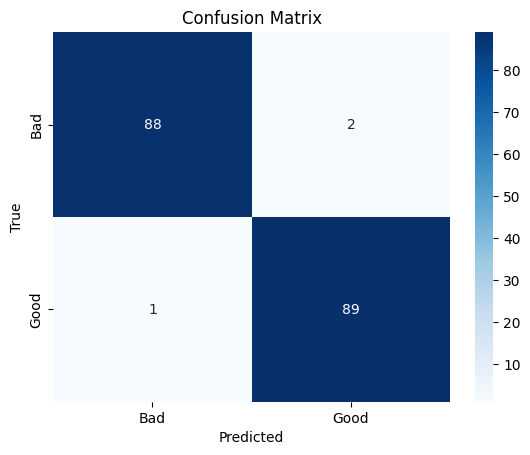

              precision    recall  f1-score   support

         Bad       0.99      0.98      0.98        90
        Good       0.98      0.99      0.98        90

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180



In [16]:
# Calculate and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print the classification report
print(classification_report(y_true, y_pred, target_names=['Bad', 'Good']))

In [17]:
# Get predictions on the test dataset
y_pred_probs = loaded_model.predict(unseen_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in unseen_ds], axis=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


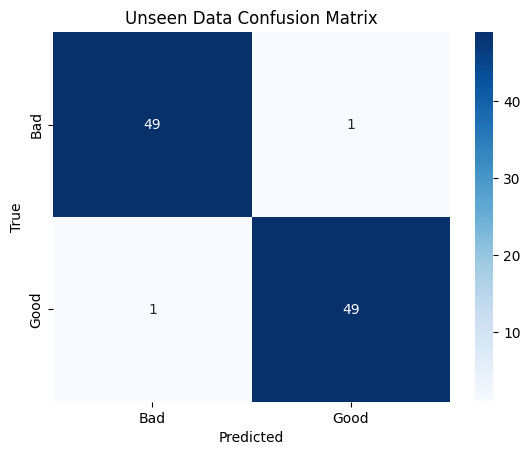

              precision    recall  f1-score   support

         Bad       0.98      0.98      0.98        50
        Good       0.98      0.98      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [18]:
# Calculate and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Unseen Data Confusion Matrix')
plt.show()

# Print the classification report
print(classification_report(y_true, y_pred, target_names=['Bad', 'Good']))

In [19]:
# download the model
model.save('/kaggle/working/model.h5')